# Minimal FEW

---

**A minimal adiabatic EMRI waveform generator. All the components that come into FEW are present, maximally simplified up to the point where it still works\***.

**Fluxes and amplitudes are computed offline, in a supplementary Mathematica notebook using the Black Hole Perturbation Toolkit (BHPT).**

**The notebook computes the inspiral for circular orbits around Schwarzschild.**

**Only dependencies are the files from Github, and numpy+scipy.**

---

*May break when changing a parameter.

## Step 1: Define some constants, and load in flux and amplitude data

In [1]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

GRAVITATIONAL_CONSTANT =  6.67408e-11
SOLAR_MASS = 1.9884754153381438e30
METERS_PER_GPC =  3.085677581491367e25
SPEED_OF_LIGHT = 299792458

from ylm import SWSH

In [2]:
lmax = 6
mmax = 6

# NUMBER OF RADIAL POINTS IN THE GRID IS 29.
re = np.fromfile("data/Ampli_real.dat", dtype=np.float64).reshape(29,lmax+1,mmax+1)
im = np.fromfile("data/Ampli_imag.dat", dtype=np.float64).reshape(29,lmax+1,mmax+1)
ampl_data = re + 1j*im


# EXTEND THE AMPLITUDE DATA, TO ALSO HAVE AMPLITUDES FOR -m. WE CAN USE Z_{-m} = (-1)**l * np.conj(Z_m)
ampl_data_ext= np.zeros((29,lmax+1,2*mmax+1), dtype=complex)
ampl_data_ext[:,:,mmax:]=ampl_data
ampl_data_ext[:,:,:mmax]=np.flip(np.conj(ampl_data[:,:,1:]),axis=2)


# THE FLUX DATA FILE CAN BE DOWNLOADED FROM THE BHPT REPO
data = np.loadtxt("data/Flux_Edot.dat")
rp = data[:, 0]
infFlux = data[:, 1]
horFlux = data[:, 2]
Edot = interp1d(rp, infFlux+horFlux, kind="cubic")

## Step 2: Define EMRI parameters

In [3]:
M = 1e6           # central BH mass
mu = 1e1          # secondary mass
a = 0             # spin
p0 = 12.0         # semi-latus rectum
e0 = 0            # eccentricity
xI0 = 1.0         # cos(inclination)
dist = 1          # distance in Gpc
theta_S = np.pi/3 #Sky angle theta_S
phi_S = np.pi/5   #Sky angle phi_S


mass_sum = M+mu                 #FEW uses the total mass
reduced_mass = M*mu/(M+mu)**2   #FEW uses the reduced mass

## Step 3: Multiply with spin-weighted-spherical-harmonics, and make interpolant from grid

In [4]:
# THE SWSH I HAVE HARD-CODED IN A SEPARATE SCRIPT

def my_SWSH(l,m,theta_S,phi_S):
    if(l>=m and l>=2 and m>0):
        return SWSH(l,m,theta_S,phi_S)
    elif(l>=np.abs(m) and l>=2 and m<0):
        return (-1)**(l)*SWSH(l,m,theta_S,phi_S)
    else:
        return 0

# ANGULAR MATRIX FOR EACH l,m, FILLED IN AT THE SKY POSITION
angular_matrix=np.array([my_SWSH(l,m,theta_S,phi_S) for l in range(lmax+1) for m in range(-mmax,mmax+1)]).reshape(lmax+1,2*mmax+1)

#MULTIPLY BOTH, AND SUM OVER THE l VALUES. 
tmp=(ampl_data_ext*angular_matrix)
SWSH_Ampls=tmp.sum(axis=(1))



# THIS IS THE RADIAL GRID I USED FOR THE AMPLITUDES
rgrid_vals = np.arange(6.5,20.6,0.5)

# MAKE INTERPOLANTS, AS FUNCTION OF R
ampl_interp_R = [interp1d(rgrid_vals, SWSH_Ampls[:, j], kind="cubic", fill_value="extrapolate") for j in range(2*mmax+1)]

## Step 4: Compute trajectory

Two differential equations, based on the geodesic parameters.

In [5]:
from scipy.integrate import solve_ivp

def solve_radial(tInf):
    """Integrate the radial function"""
    
    def drdE(r):
        return 2*(r*(r-3))**(3/2)/(r-6)

    def dydt(t,y):
        return -reduced_mass*drdE(y)*Edot(y)

    solRadial = solve_ivp(
        dydt,
        t_span=(0, tInf),
        y0=[p0],
        dense_output=True,
        method='RK45',
        rtol=1e-10,
        atol=1e-12
    )

    return solRadial


def solve_angular(solRadial,tInf):
    """Integrate the angular function"""
    
    def dydt(t,y):
        return solRadial.sol(t)**(-3/2)

    solAngular = solve_ivp(
        dydt,
        t_span=(0, tInf),   # integrate from t=0 to t=5
        y0=[0],        # initial condition
        dense_output=True,
        method='RK45', 
        rtol=1e-10, 
        atol=1e-12
    )

    return solAngular


# IN THIS SIMPLE DEMO, I DID NOT INCLUDE A STOPPING CONDITION. WITH THE PARAMETERS GIVEN, WE CAN EVOLVE UP TO ~2.5e7 SECONDS.
solRadial = solve_radial(2.5e7)
solAngular = solve_angular(solRadial,2.5e7)

## Step 5: Wavefunction, including scaling to physical units.

In [6]:
# EVERYTHING IN BHPT IS SCALED BY THE MASS. THESE ARE THE FACTORS TO GO TO PHYSICAL UNITS
time_unit = GRAVITATIONAL_CONSTANT*SOLAR_MASS*mass_sum/(SPEED_OF_LIGHT**3)
radiusUnit = GRAVITATIONAL_CONSTANT*SOLAR_MASS*mass_sum/SPEED_OF_LIGHT**2

#THE FINAL SCALE FACTOR, GIVING THE 1/dist SCALING.
scaleFactor = reduced_mass*radiusUnit/(dist*METERS_PER_GPC)


def ampl_interp_T(time,m):
    """Amplitude interpolant as a function on time. """
    return ampl_interp_R[m+mmax](solRadial.sol(time/time_unit)[0]) #TIME IS IN SECONDS HERE


def wf_complex(time,m):
    """The full waveform function."""
    return scaleFactor*ampl_interp_T(time,m)*np.exp(1j*m*solAngular.sol(time/time_unit)[0])*np.exp(-1j*m*phi_S)

## Step 6: Compute the waveform on the time-grid

In [7]:
time_grid = np.arange(0,2.5e7,20)

wf_grid = np.sum([wf_complex(time_grid,m) for m in range(-mmax,mmax+1)],axis=0)

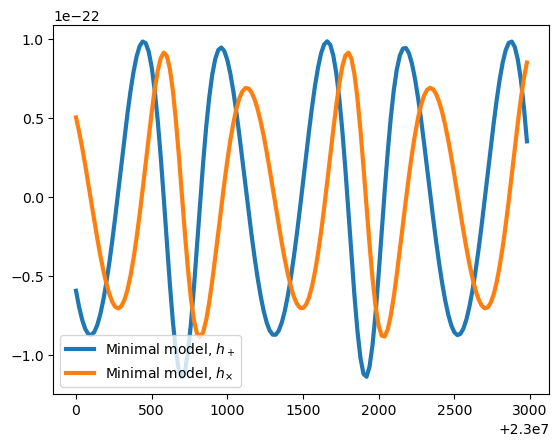

In [12]:
dtS=20
start=int(2.3e7/dtS)
edge = int(3000/dtS)


plt.plot(time_grid[start:start+edge], np.real(wf_grid[start:start+edge]),"-",linewidth=3,label=r"Minimal model, $h_+$")
plt.plot(time_grid[start:start+edge], np.imag(wf_grid[start:start+edge]),"-",linewidth=3,label=r"Minimal model, $h_{\times}$")
plt.legend()

plt.show()

## Step 7: Do we get the same with FEW?

In [9]:
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
waveform_generator = GenerateEMRIWaveform(FastKerrEccentricEquatorialFlux)
from lisaconstants import (
        ASTRONOMICAL_YEAR,
)

In [10]:
dtS=20
Ts=2.5e7/ASTRONOMICAL_YEAR

wf_FEW = waveform_generator(
    M,         # m_1
    mu,        # m_2
    0,         # a
    p0,        # p_0
    0,         # e_0
    1.,        # xI_0
    dist,      # luminosity distance (Gpc)
    theta_S,   # theta_S, polar sky angle
    phi_S,     # phi_S, azimuthal sky angle
    0,         # theta_K, polar angle of primary spin-momentum vector
    0,         # phi_K, azimuthal angle of primary spin-momentum vector
    0,         # Phi_phi0, initial azimuthal orbital phase
    0,         # Phi_theta0, initial polar orbital phase
    0,         # Phi_r0, initial radial orbital phase
    T=Ts,      # duration in years (see few.utils.constants.YRSID_SI for the definition of a year)
    dt=dtS,    # sampling cadence in seconds
)


time = np.arange(0,ASTRONOMICAL_YEAR * Ts, dtS)

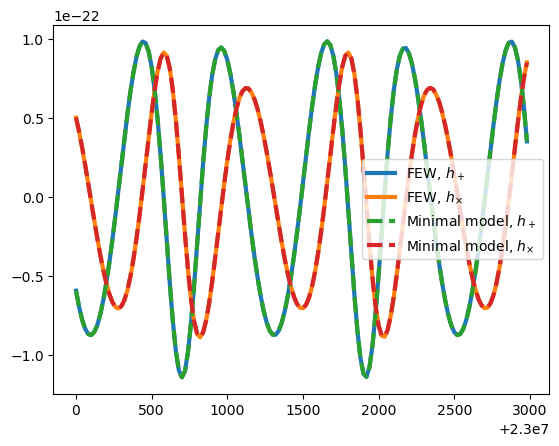

In [17]:
start=int(2.3e7/dtS)
edge = int(3000/dtS)

plt.plot(time[start:start+edge],wf_FEW.real[start:start+edge],linewidth=3,label=r"FEW, $h_+$")
plt.plot(time[start:start+edge],wf_FEW.imag[start:start+edge],linewidth=3,label=r"FEW, $h_{\times}$")

plt.plot(time_grid[start:start+edge], np.real(wf_grid[start:start+edge]),"--",linewidth=3,label=r"Minimal model, $h_+$")
plt.plot(time_grid[start:start+edge], np.imag(wf_grid[start:start+edge]),"--",linewidth=3,label=r"Minimal model, $h_{\times}$")
plt.legend()

plt.show()